# BÀI THỰC HÀNH CHƯƠNG 2 (PHẦN 2): CANNY EDGE DETECTOR
# PHẦN II — THỰC HÀNH CODE
---

## 2.0. Cài đặt và Import thư viện

In [1]:
# ============================================================
# Import thư viện
# ============================================================
import cv2
# Thao tác với ma trận 
import numpy as np 
# Dùng hiển thị ảnh, biểu đồ,...
import matplotlib.pyplot as plt
# Thường dùng cho các bộ lọc mờ, nhiễu, các phép toán hình thái học
from scipy import ndimage  #N-dimensional image
# Thư viện của bộ lọc thư viện scikit-image, có nhiều thuật toán xử lý ảnh nâng cao
from skimage.feature import canny as skimage_canny
# Cấu hình hiển thị
%matplotlib inline 
# kích cỡ khung mặc định (14 inch rộng x 8 inch dài)
plt.rcParams['figure.figsize'] = (14, 8)
# cỡ chữ chú thích
plt.rcParams['font.size'] = 12
# cỡ chữ tiêu đề
plt.rcParams['axes.titlesize'] = 14
# độ phân giải hiển thị (100 điểm ảnh trên mỗi inch)
plt.rcParams['figure.dpi'] = 100

print(f"OpenCV version: {cv2.__version__}")
print("Import thành công! ")

OpenCV version: 4.13.0
Import thành công! 


In [2]:
# ============================================================
# Các hàm tiện ích (dùng chung trong Notebook)
# ============================================================

def show_images(images, titles, rows=1, figsize=(16, 6)):
    
    """Hàm hiển thị nhiều ảnh trên cùng một dòng hoặc lưới."""
    # Nếu dư thì cộng với số dư đó để thêm cột
    cols = len(images) // rows + (1 if len(images) % rows != 0 else 0)    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1 and cols == 1: axes = [axes]  #[ảnh 1, ảnh 2, ảnh 3, ảnh 4]
    elif rows == 1 or cols == 1: axes = axes.flatten() #[[ô 1, ô 2], [ô 3, ô 4]]
    # Làm phẳng mảng 2 chiều thành 1 chiều
    else: axes = axes.flatten()
    
    for i, (img, title) in enumerate(zip(images, titles)):
        ax = axes[i]
        if len(img.shape) == 2:
            # Ảnh xám
            ax.imshow(img, cmap='gray')
        else:
            # Ảnh màu (chuyển BGR của OpenCV sang RGB để hiển thị đúng màu bằng Matplotlib)
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontweight='bold')
        ax.axis('off')
        
    for j in range(len(images), len(axes)): axes[j].axis('off')
   # Ví dụ có 5 ảnh nhưng lưới hiển thị là 6 ô (2 hàng x 3 cột):
    # Hàng 1: [ Ảnh 1 ]  [ Ảnh 2 ]  [ Ảnh 3 ]
    # Hàng 2: [ Ảnh 4 ]  [ Ảnh 5 ]  [ Biểu đồ ]
    plt.tight_layout()
    plt.show()

def print_edge_stats(name, edges):
    """In số lượng pixel là cạnh trên tổng pixel."""
    count = np.sum(edges) if edges.dtype == bool else np.sum(edges > 0)
    total = edges.size
    print(f"  [{name}] Pixels cạnh: {count} / {total} ({count / total * 100:.2f}%)")  #12.34567 thành 12.35% 

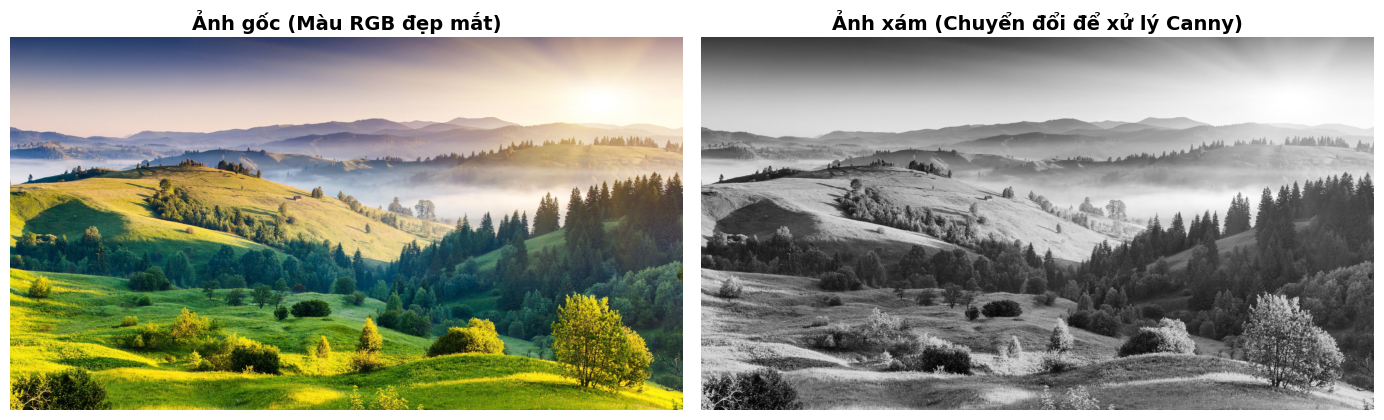

Kích thước: (2126, 3840) | Dtype: uint8


In [3]:
# ============================================================
# Tải ảnh chính: Đồi 
# Mục đích: Dùng làm ảnh chuẩn cho phần II.1 và II.2
# ============================================================

image_path = 'image/chuong2.jpg'
# Đọc ảnh dưới dạng màu (BGR) để hiển thị đẹp mắt cho người dùng
img_color = cv2.imread(image_path)




img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
img_float = img_gray.astype(np.float64) / 255.0 #100 --> float là 100.0  lấy số này / 255.0

show_images(
    [img_color, img_gray],
    ['Ảnh gốc (Màu RGB đẹp mắt)', 'Ảnh xám (Chuyển đổi để xử lý Canny)'],
    figsize=(14, 5)
)
print(f"Kích thước: {img_gray.shape} | Dtype: {img_gray.dtype}")

---
## 2.1. Thực hiện Canny bằng các thư viện

### a) Canny với OpenCV (`cv2.Canny`)
Sử dụng ảnh Đồi Núi để minh họa thuật toán Canny cơ bản.

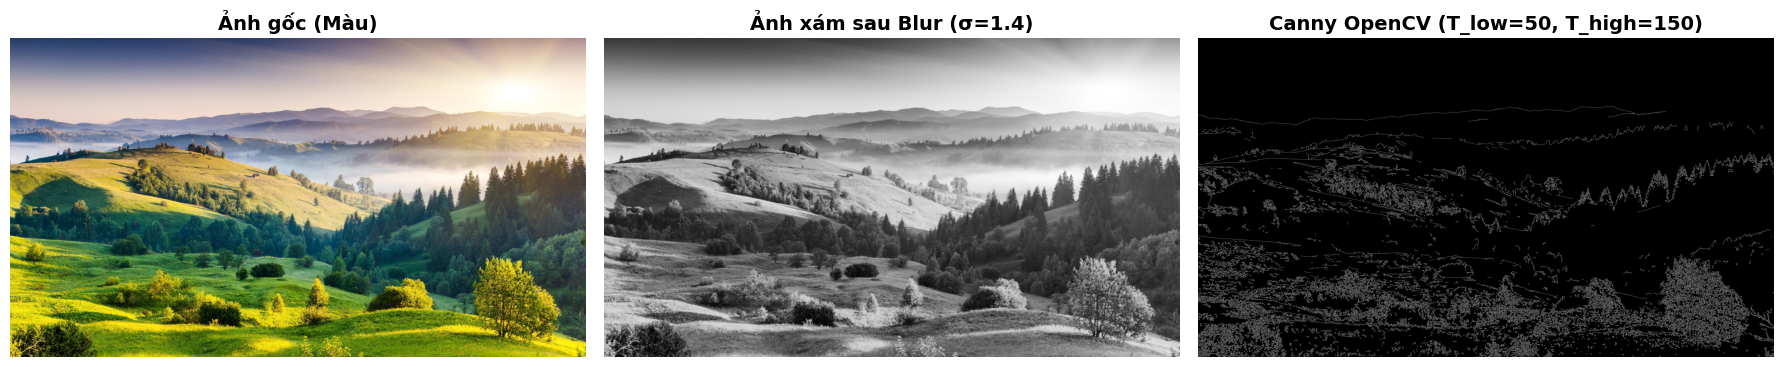

KẾT QUẢ CANNY - OPENCV
  [OpenCV Canny] Pixels cạnh: 367499 / 8163840 (4.50%)


In [4]:
# ============================================================
# 2.1a - OpenCV Canny trên ảnh Đồi Núi
# ============================================================

# Giảm nhiễu bằng Gaussian Blur trên ảnh xám
img_blur = cv2.GaussianBlur(img_gray, (5, 5), sigmaX=1.4)

# Áp dụng Canny: threshold1=ngưỡng thấp, threshold2=ngưỡng cao
# Các giá trị ngưỡng được giữ lại tạm thời để sét cạnh gần với các ngưỡng không
edges_cv2 = cv2.Canny(img_blur, threshold1=50, threshold2=150)

# Hiển thị
show_images(
    [img_color, img_blur, edges_cv2],
    ['Ảnh gốc (Màu)', 'Ảnh xám sau Blur (σ=1.4)',
     'Canny OpenCV (T_low=50, T_high=150)'],
    figsize=(18, 5)
)

print("KẾT QUẢ CANNY - OPENCV")
print_edge_stats("OpenCV Canny", edges_cv2)

### b) Canny với Scikit-image (`skimage.feature.canny`)

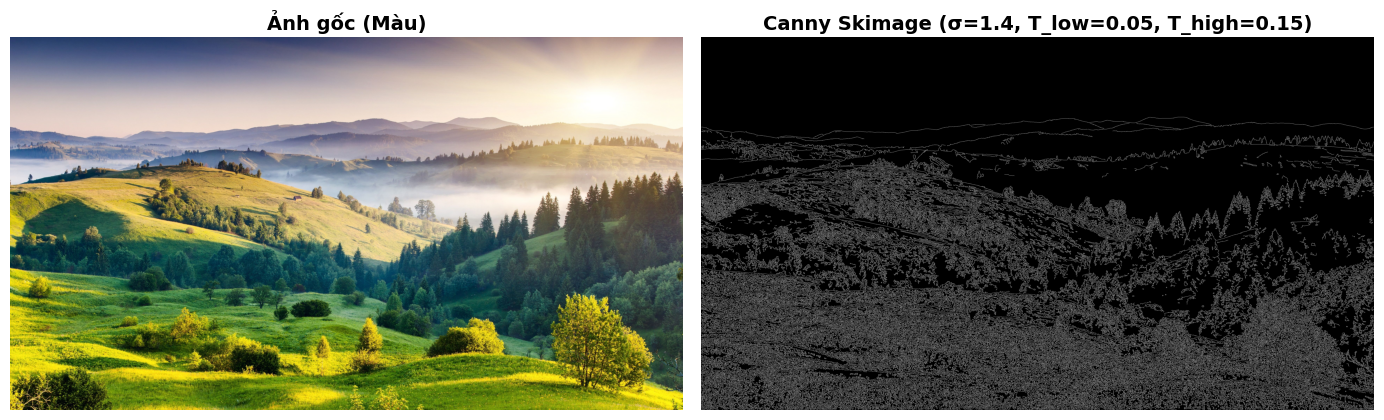

KẾT QUẢ CANNY - SCIKIT-IMAGE
  [Skimage Canny] Pixels cạnh: 868369 / 8163840 (10.64%)


In [5]:
# ============================================================
# 2.1b - Scikit-image Canny trên ảnh Cầu Ba Son
# ============================================================

# skimage tích hợp sẵn Gaussian blur bên trong hàm canny()
# Ngưỡng là giá trị float [0, 1] (khác với OpenCV dùng [0, 255])
# Thường sử dụng lọc sobel <=> gaussian
edges_skimage = skimage_canny(
    img_float,
    sigma=1.4,            
    low_threshold=0.05,   
    high_threshold=0.15   
)

show_images(
    [img_color, edges_skimage.astype(np.uint8) * 255],
    ['Ảnh gốc (Màu)', 'Canny Skimage (σ=1.4, T_low=0.05, T_high=0.15)'],
    figsize=(14, 5)
)

print("KẾT QUẢ CANNY - SCIKIT-IMAGE")
print_edge_stats("Skimage Canny", edges_skimage)

---
## 2.2. Thay đổi tham số và quan sát kết quả trên ảnh Đồi Núi

### a) Ảnh hưởng của Sigma (σ)
Sigma xác định mức độ làm mịn của bộ lọc Gaussian. Ảnh Đồi Núi có nhiều chi tiết kiến trúc, hãy xem Sigma ảnh hưởng thế nào.

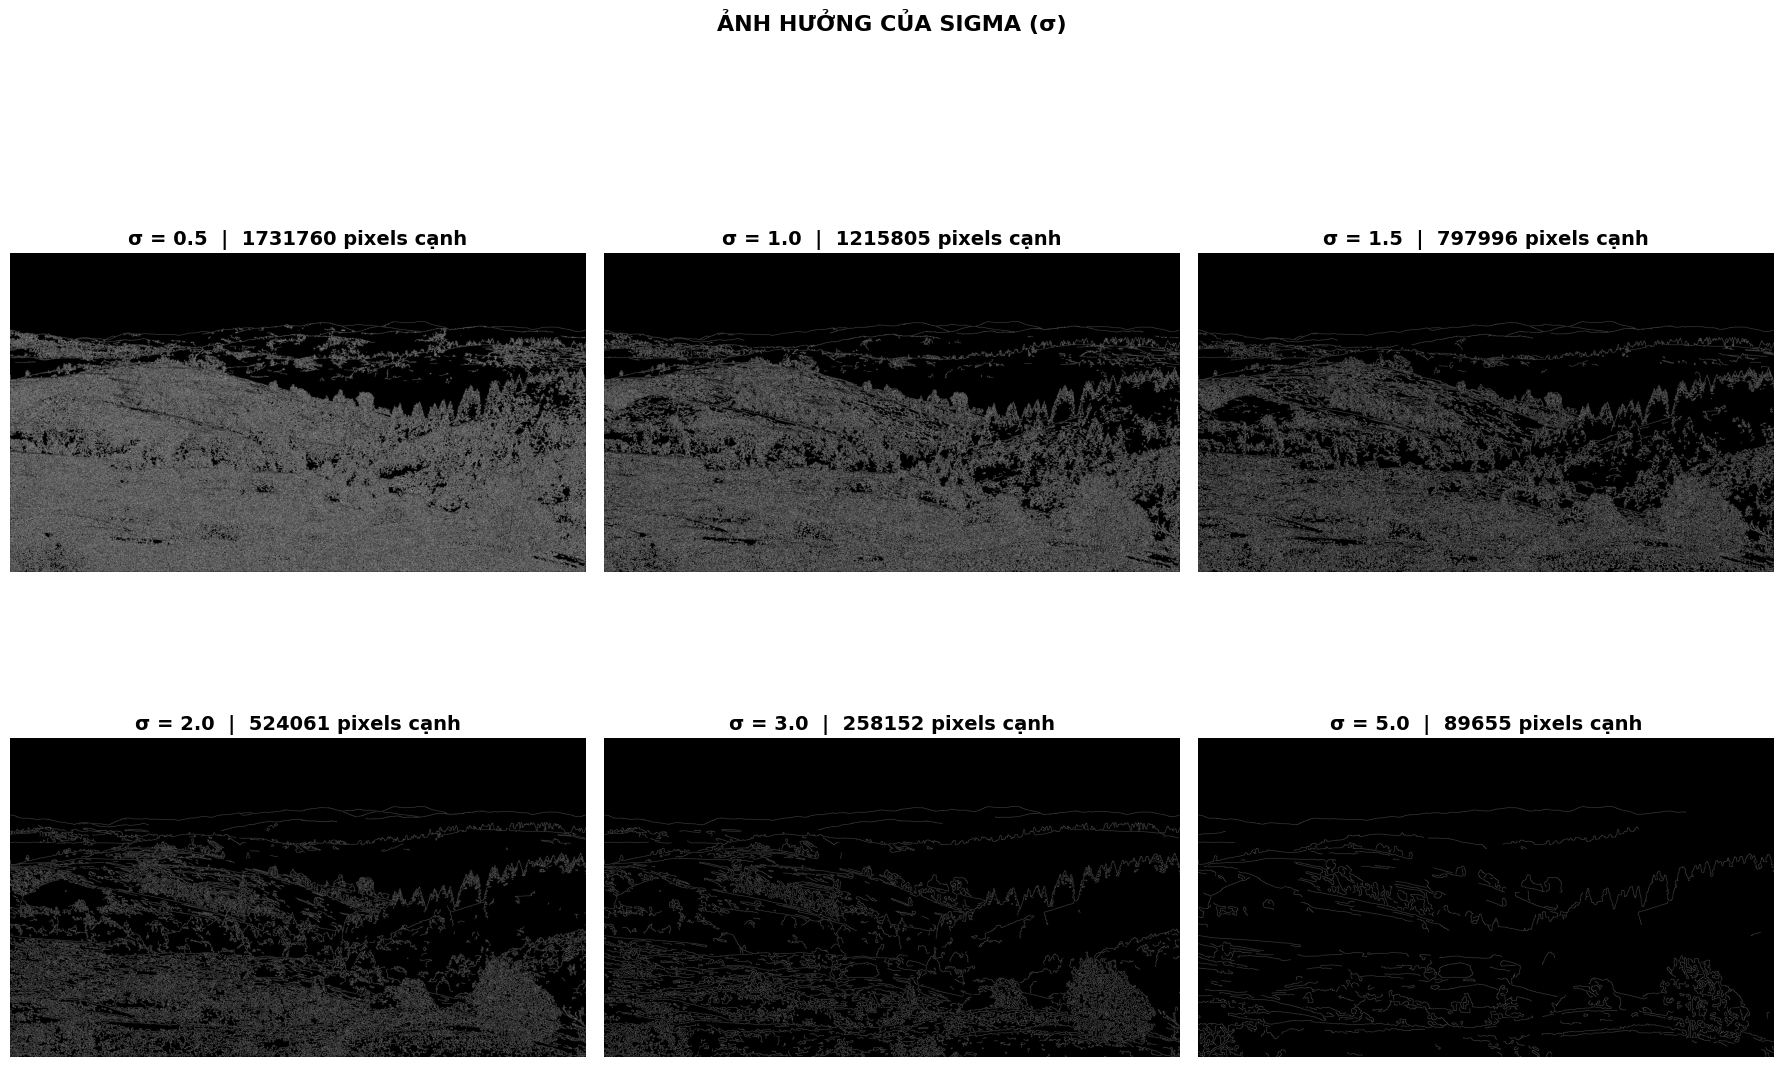

📌 σ nhỏ → giữ lại cạnh của đồi, chi tiết nhỏ | σ lớn → chỉ giữ lại đường viền chính của đồi.


In [6]:
# ============================================================
# 2.2a - Khảo sát Sigma
# ============================================================

sigma_values = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
edge_counts = []

for i, sigma in enumerate(sigma_values):
    edges = skimage_canny(img_float, sigma=sigma,
                          low_threshold=0.05, high_threshold=0.15)
    count = np.sum(edges)
    edge_counts.append(count)
    ax = axes[i // 3, i % 3]
    ax.imshow(edges, cmap='gray')
    ax.set_title(f'σ = {sigma}  |  {count} pixels cạnh', fontweight='bold')
    ax.axis('off')

plt.suptitle('ẢNH HƯỞNG CỦA SIGMA (σ)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📌 σ nhỏ → giữ lại cạnh của đồi, chi tiết nhỏ | σ lớn → chỉ giữ lại đường viền chính của đồi.")

### b) Ảnh hưởng của ngưỡng thấp và ngưỡng cao

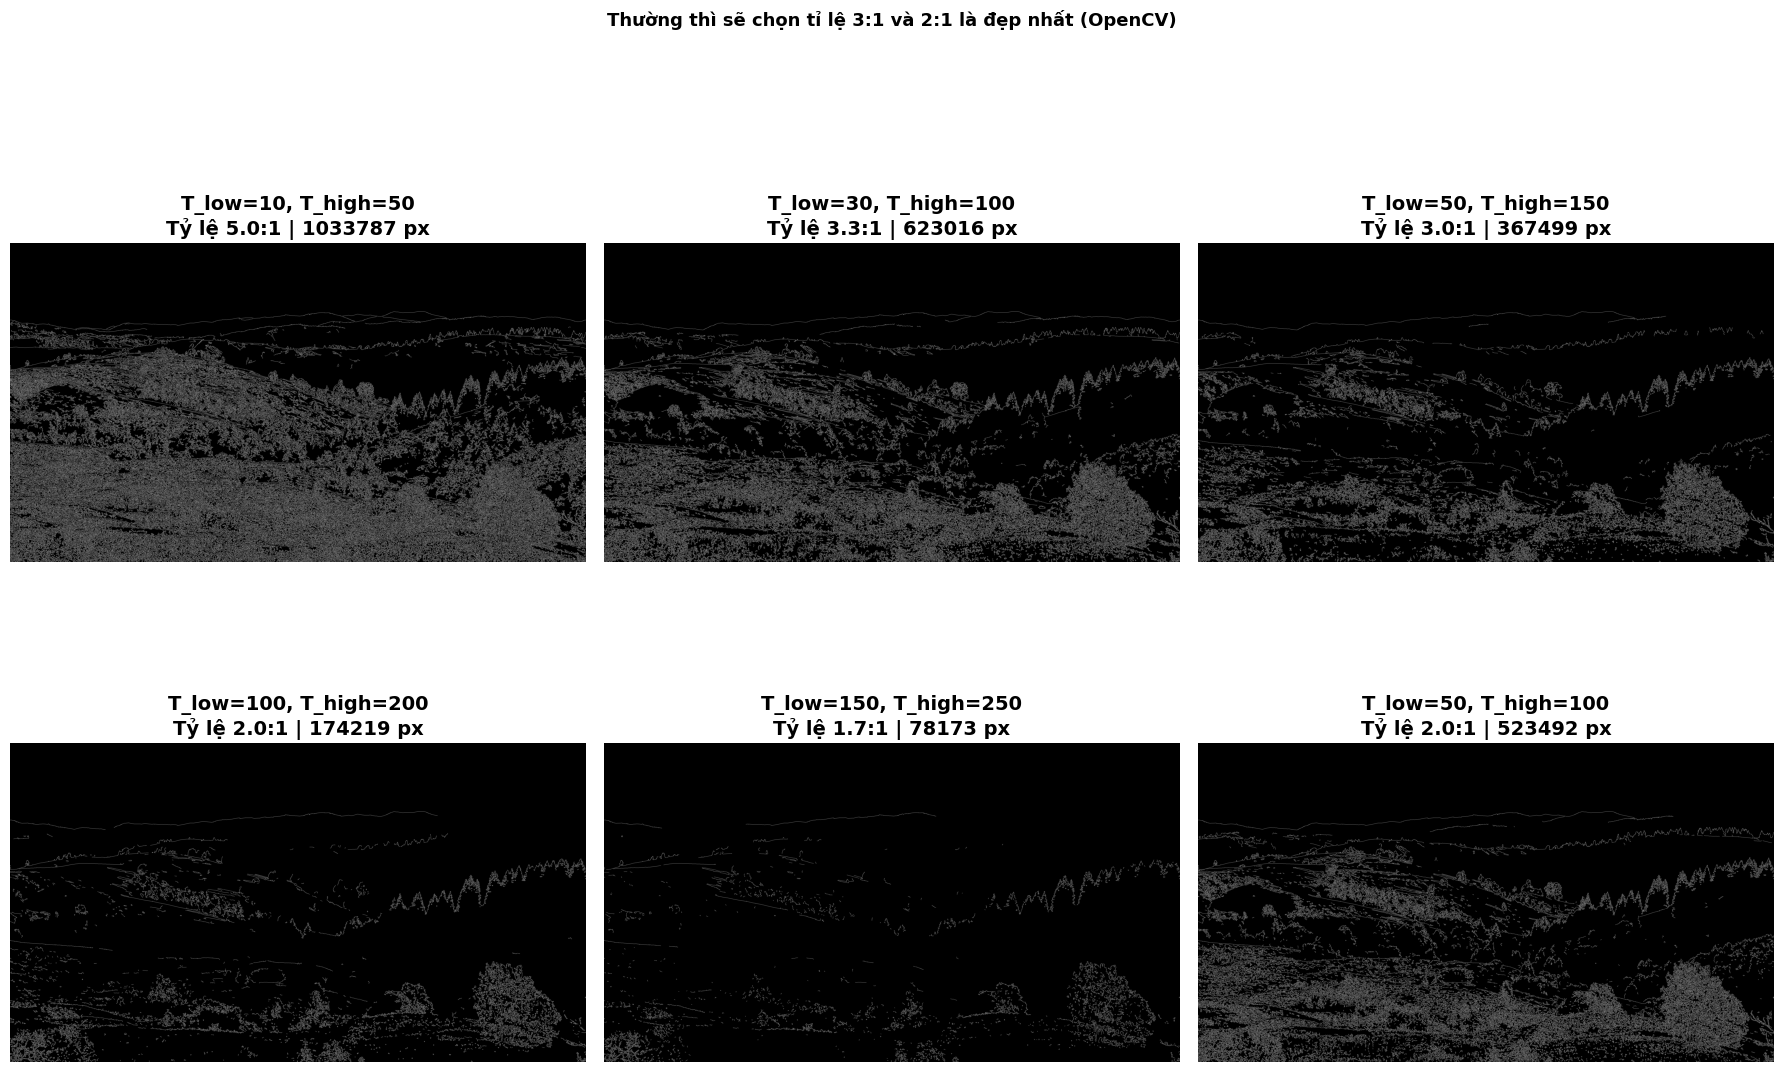

In [7]:
# ============================================================
# 2.2b - Khảo sát ngưỡng (OpenCV)
# ============================================================

threshold_pairs = [
    (10, 50), (30, 100), (50, 150),
    (100, 200), (150, 250), (50, 100),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, (t_low, t_high) in enumerate(threshold_pairs):
    edges = cv2.Canny(img_blur, t_low, t_high)
    count = np.sum(edges > 0)
    ratio = t_high / t_low
    ax = axes[i // 3, i % 3]
    ax.imshow(edges, cmap='gray')
    ax.set_title(f'T_low={t_low}, T_high={t_high}\n'
                 f'Tỷ lệ {ratio:.1f}:1 | {count} px', fontweight='bold')
    ax.axis('off')

plt.suptitle('ẢNH HƯỞNG CỦA NGƯỠNG (OpenCV)', fontsize=16, fontweight='bold', y=1.02)
plt.suptitle('Thường thì sẽ chọn tỉ lệ 3:1 và 2:1 là đẹp nhất (OpenCV)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 2.3. Canny trên các loại ảnh thực tế đặc thù

### a) Ảnh sương mù, tương phản thấp (Đà Lạt)
Cần tinh chỉnh ngưỡng thấp xuống để bắt được các đường viền mờ trong sương.

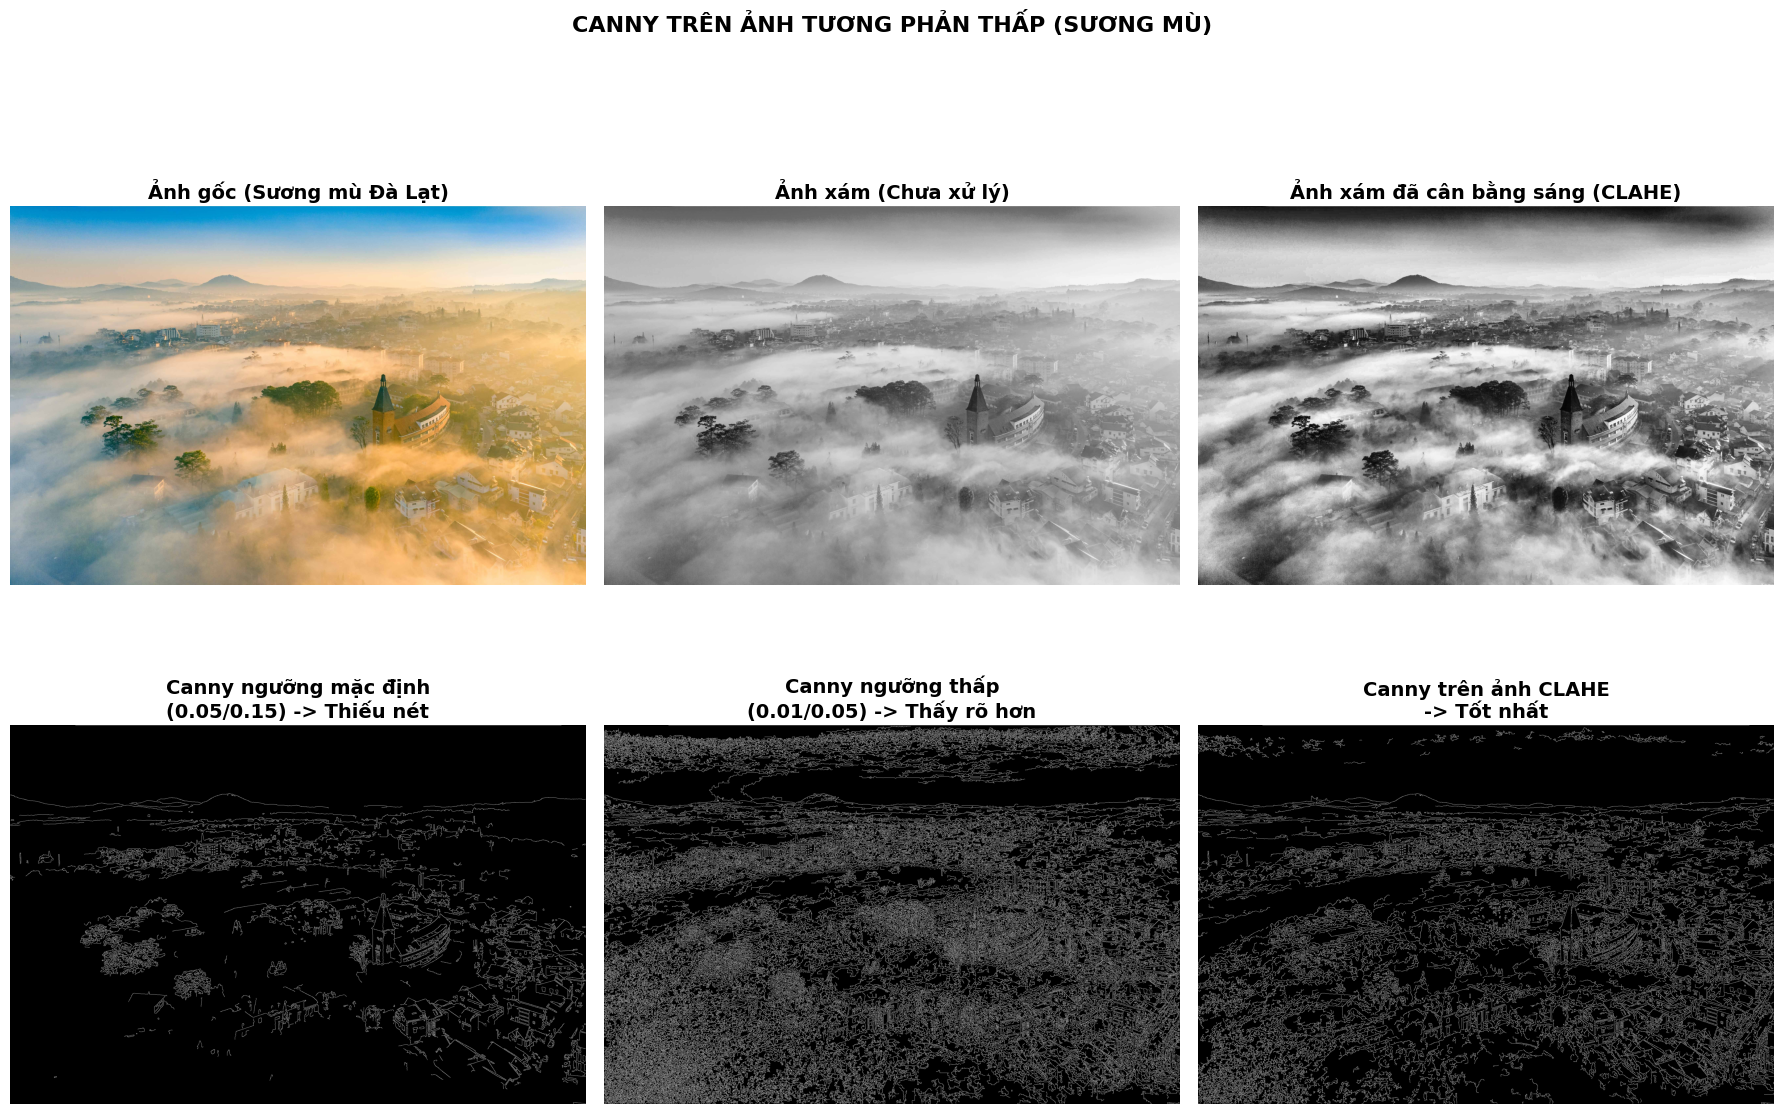

📌 Tương phản thấp → ít cạnh. Giải pháp: Sử dụng CLAHE để cân bằng sáng hoặc giảm ngưỡng cực thấp.


In [ ]:
# ============================================================
# 2.3a - Ảnh sương mù Đà Lạt
# ============================================================

img_fog_path = 'image/suongmu.jpg'

img_fog_color = cv2.imread(img_fog_path)

img_fog_gray = cv2.cvtColor(img_fog_color, cv2.COLOR_BGR2GRAY)
img_fog_f = img_fog_gray.astype(np.float64) / 255.0

#  CLAHE (Contrast Limited Adaptive Histogram Equalization)
# Tăng độ tương phản lên gắp 3 lần từng vùng nhỏ (8x8) để làm rõ chi tiết trong ảnh sương mù 
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))         
img_fog_enh = clahe.apply(img_fog_gray)
img_fog_enh_f = img_fog_enh.astype(np.float64) / 255.0


edges_fog_default = skimage_canny(img_fog_f, sigma=1.4, low_threshold=0.05, high_threshold=0.15)
edges_fog_tuned = skimage_canny(img_fog_f, sigma=1.0, low_threshold=0.01, high_threshold=0.05) 
edges_fog_clahe = skimage_canny(img_fog_enh_f, sigma=1.4, low_threshold=0.05, high_threshold=0.15)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))


axes[0,0].imshow(cv2.cvtColor(img_fog_color, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('Ảnh gốc (Sương mù Đà Lạt)', fontweight='bold')

axes[0,1].imshow(img_fog_gray, cmap='gray')
axes[0,1].set_title('Ảnh xám (Chưa xử lý)', fontweight='bold')

axes[0,2].imshow(img_fog_enh, cmap='gray')
axes[0,2].set_title('Ảnh xám đã cân bằng sáng (CLAHE)', fontweight='bold')

axes[1,0].imshow(edges_fog_default, cmap='gray')
axes[1,0].set_title(f'Canny ngưỡng mặc định\n(0.05/0.15) -> Thiếu nét', fontweight='bold')

axes[1,1].imshow(edges_fog_tuned, cmap='gray')
axes[1,1].set_title(f'Canny ngưỡng thấp\n(0.01/0.05) -> Thấy rõ hơn', fontweight='bold')

axes[1,2].imshow(edges_fog_clahe, cmap='gray')
axes[1,2].set_title(f'Canny trên ảnh CLAHE\n-> Tốt nhất', fontweight='bold')

for ax in axes.flatten(): ax.axis('off')
plt.suptitle('CANNY TRÊN ẢNH TƯƠNG PHẢN THẤP (SƯƠNG MÙ)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📌 Tương phản thấp → ít cạnh. Giải pháp: Sử dụng CLAHE để cân bằng sáng hoặc giảm ngưỡng cực thấp.")

### b) Ảnh nhiều chi tiết (Cao tốc)
Ảnh chụp đường xá, xe cộ từ trên cao có rất nhiều chi tiết đường thẳng và xe.

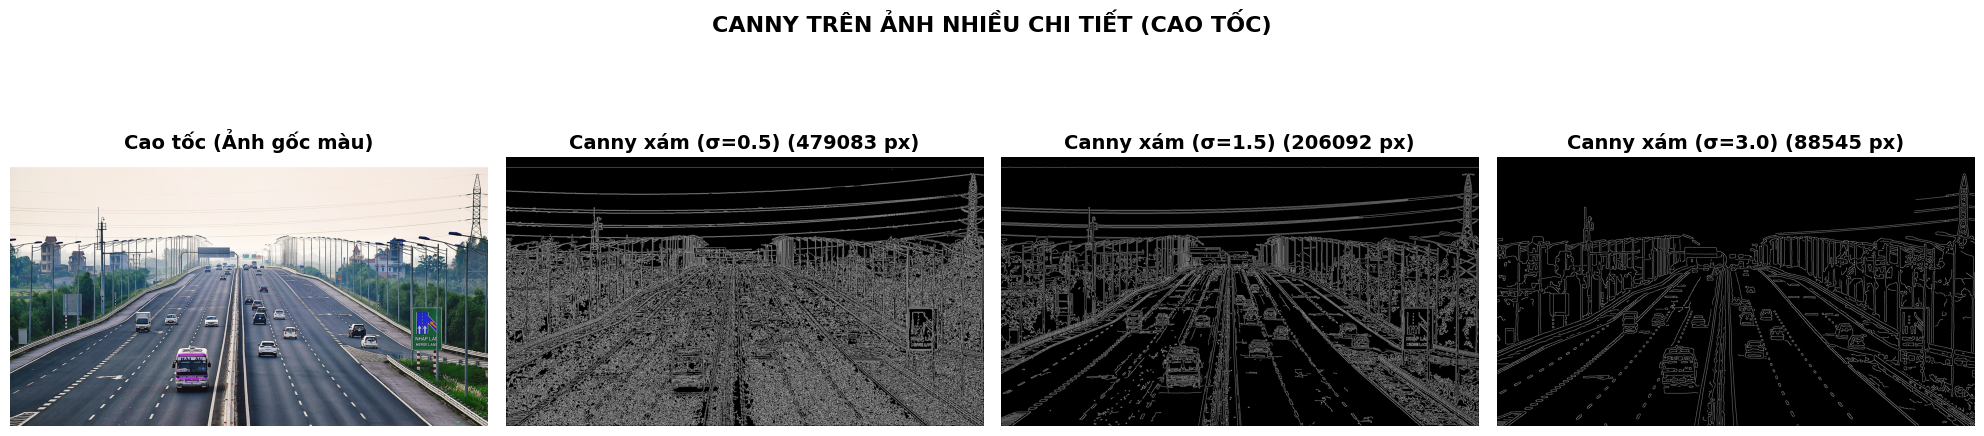

📌 σ nhỏ → phát hiện mọi vạch kẻ đường, xe cộ | σ lớn → chỉ giữ lại lề đường chính


In [9]:
# ============================================================
# 2.3b - Ảnh nhiều chi tiết Cao tốc
# ============================================================

img_road_path = 'image/caotoc.jpg'
img_road_color = cv2.imread(img_road_path)


img_road_gray = cv2.cvtColor(img_road_color, cv2.COLOR_BGR2GRAY)
road_f = img_road_gray.astype(np.float64) / 255.0

sigmas = [0.5, 1.5, 3.0]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))


axes[0].imshow(cv2.cvtColor(img_road_color, cv2.COLOR_BGR2RGB))
axes[0].set_title('Cao tốc (Ảnh gốc màu)', fontweight='bold')

for i, sigma in enumerate(sigmas):
    e_road = skimage_canny(road_f, sigma=sigma, low_threshold=0.04, high_threshold=0.12)
    axes[i+1].imshow(e_road, cmap='gray')
    axes[i+1].set_title(f'Canny xám (σ={sigma}) ({np.sum(e_road)} px)', fontweight='bold')

for ax in axes.flatten(): ax.axis('off')
plt.suptitle('CANNY TRÊN ẢNH NHIỀU CHI TIẾT (CAO TỐC)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📌 σ nhỏ → phát hiện mọi vạch kẻ đường, xe cộ | σ lớn → chỉ giữ lại lề đường chính")

---
## 2.4. Kết hợp Canny với các kỹ thuật khác

### Nhận diện hình tròn (Vòng Xoay)
Sử dụng Canny kết hợp Hough Circles để tìm ra khu vực vòng xoay đặc trưng của Vòng Xoay
.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23484\2941087008.py:29: RuntimeWarning: overflow encountered in scalar subtract
  cv2.putText(result_circles, "Vong Xoay", (x - 40, y - r - 10),  # còn đây là vị trí để để text ra vị trí mình mong muốn ở giữa


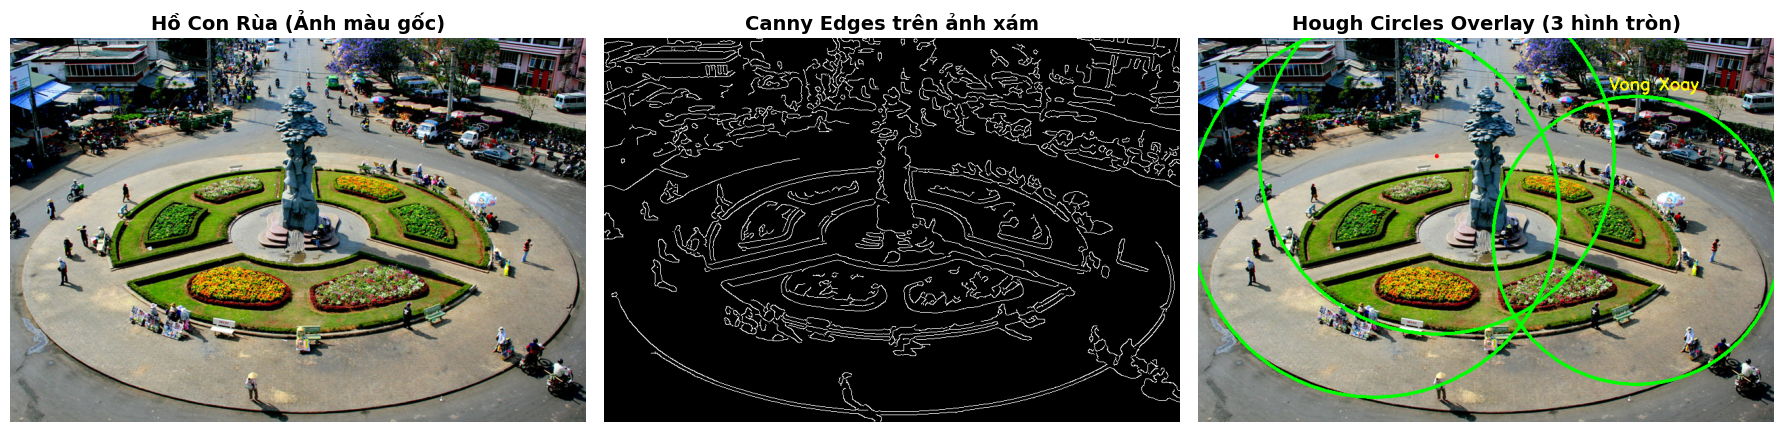

📌 Đã phát hiện 3 vòng xoay/hình tròn.


In [10]:
# ============================================================
# 2.4 - Nhận dạng khối hình học tròn
# ============================================================

img_turtle_path = 'image/vongxoay.jpg'
img_turtle_color = cv2.imread(img_turtle_path)

img_turtle_gray = cv2.cvtColor(img_turtle_color, cv2.COLOR_BGR2GRAY)
# Ma trận 9x9 xích ma 2
turtle_blur = cv2.GaussianBlur(img_turtle_gray, (9, 9), 2)


# Tham số param1 chính là Canny high_threshold, param2 là accumulator threshold
circles = cv2.HoughCircles(
    turtle_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=100,
    param1=150, param2=40, minRadius=200, maxRadius=280
)



result_circles = img_turtle_color.copy() # sử dụng một biến để sao lưu bản gốc tránh việc bản gốc bị thay đổi 
n_circles = 0
if circles is not None:  # not none ở đây tồn tại để nếu mà không phát hiện được bất kỳ hình tròn thì nó trả về none không tìm thấy tránh crash lỗi chương trình
    circles = np.uint16(np.around(circles)) #uint16 ép kiểu dữ liệu thành số nguyên dương không âm around ở đây tồn tại để làm tròn kết quả tính toán được
    n_circles = len(circles[0]) # len(circles[o]) dùng để đếm được bao nhiêu hình tròn tìm thấy được 
    for (x, y, r) in circles[0]:# vòng lặp đi qua từng hình tròn x là tọa độ ngang của tâm và y là tọa độ dọc của tâm , r là là bán kính 
        cv2.circle(result_circles, (x, y), r, (0, 255, 0), 3) # Viền xanh 255 của Green với bán kính r là 3 pixel
        cv2.circle(result_circles, (x, y), 3, (0, 0, 255), -1) # ở đây được truyền vào bảng màu đỏ 255 và bánh kính là 3 pixel -1 ở đây là một mẹo trong open cv để vẽ tô đậm nét ở bên trong hình tròn 
        cv2.putText(result_circles, "Vong Xoay", (x - 40, y - r - 10),  # còn đây là vị trí để để text ra vị trí mình mong muốn ở giữa
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2) # 0.8 là cỡ chữ 2 ở đây là độ dài nét chữ 


edges_turtle = cv2.Canny(turtle_blur, 50, 150) 

show_images(
    [img_turtle_color, edges_turtle, result_circles],
    ['Hồ Con Rùa (Ảnh màu gốc)', 'Canny Edges trên ảnh xám', f'Hough Circles Overlay ({n_circles} hình tròn)'],
    figsize=(18, 6)
)
print(f"📌 Đã phát hiện {n_circles} vòng xoay/hình tròn.")